# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 30 dias | Ventana salida: 30 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [2]:
VENTANA_ENTRADA = 30   # dias de entrada
VENTANA_SALIDA  = 30   # dias de salida (promedio)


In [33]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import construir_baseline_lineal, construir_dense, construir_dense_v2, construir_dense_v3, construir_dense_v4, construir_dense_v5, construir_dense_v6, construir_recurrente, construir_conv1d, construir_mixto
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae

from utilidades.tuning import ofat_search, plot_best_history

CALLBACKS = [
  #  EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor ='val_loss', factor=0.5, patience=3,  min_delta=1e-5, min_lr=1e-8, verbose=1),
]


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [4]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16131, 30, 23)  |  y: (16131, 23)
Train: (13791, 30, 23)  Val: (726, 30, 23)  Test: (1614, 30, 23)


## 1.2 Baselines

In [5]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.002098  0.002253  0.002428         0
BuyAndHold   0.002153  0.002185  0.002320         0


## 1.3 Modelo Dense (MLP)

In [8]:
modelo_lineal = construir_baseline_lineal(X_train_plano.shape[1], y_train.shape[1])
modelo_lineal.summary()
hist_dense_lineal = modelo_lineal.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
   epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Lineal_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │        15,893 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,893 (62.08 KB)

 Trainable params: 15,893 (62.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0178 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0171 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0163 - val_loss: 0.0160 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0156 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0150 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0144 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0139 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0134 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0130 - val_loss: 0.0129 - learning_rate: 0.0010
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━

In [25]:
modelo_dense_1 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_1.summary()
hist_dense_1 = modelo_dense_1.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=100, callbacks=CALLBACKS, verbose=1)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0027 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 3/50
130/138 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 6/50
135/138 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.00

In [10]:
modelo_dense_2 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_2.summary()
hist_dense_2 = modelo_dense_2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.0132 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0090 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0074
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0071 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0054 - val_loss: 0.0039 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0046 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0040
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0040 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0035 - val_loss: 0.0029 - le

In [11]:
modelo_dense_3 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_3.summary()
hist_dense_3 = modelo_dense_3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.0139 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0089 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0070
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0068 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0053 - val_loss: 0.0039 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0046 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0040
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0039 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0035 - val_loss: 0.0029 -

In [12]:
modelo_dense_4 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_4.summary()
hist_dense_4 = modelo_dense_4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0133 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0090 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0072
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0070 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0054 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0047 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0041
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0041 - val_loss: 0.0031 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0036 - val_loss: 0.0029 - l

In [13]:
modelo_dense_5 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_5.summary()
hist_dense_5 = modelo_dense_5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - loss: 0.0125 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0085 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0068
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0065 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0049 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0042 - val_loss: 0.0031 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0037
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0036 - val_loss: 0.0028 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0032 - val_loss: 0.0027 - 

In [23]:
modelo_dense_6 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_6.summary()
hist_dense_6 = modelo_dense_6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=100, callbacks=CALLBACKS, verbose=1)

Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │       176,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,759 (831.09 KB)

 Trainable params: 212,759 (831.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0028 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/50
133/138 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 7/50
128/138 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022 -

{'modelo': 'Lineal', 'mae_train': 0.002259986150094618, 'mae_val': 0.0024653232321991355, 'mae_test': 0.002631342819614919, 'n_params': 15893}


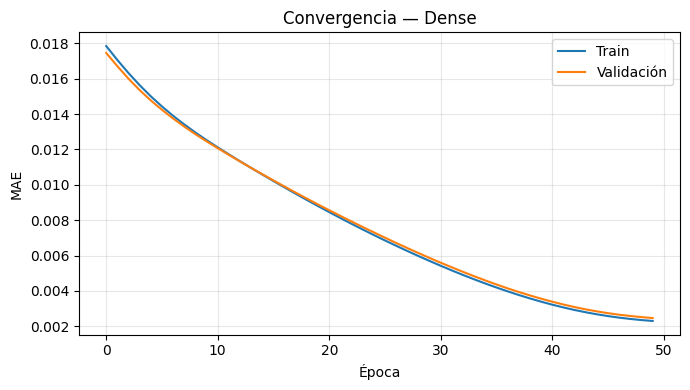

In [24]:
graficar_convergencia(hist_dense_lineal, 'Dense')
resultado_lineal = evaluar_modelo(modelo_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
print(resultado_lineal)

{'modelo': 'Dense', 'mae_train': 0.0021496722661359987, 'mae_val': 0.0021827451625502756, 'mae_test': 0.0023197170760763824, 'n_params': 212759}


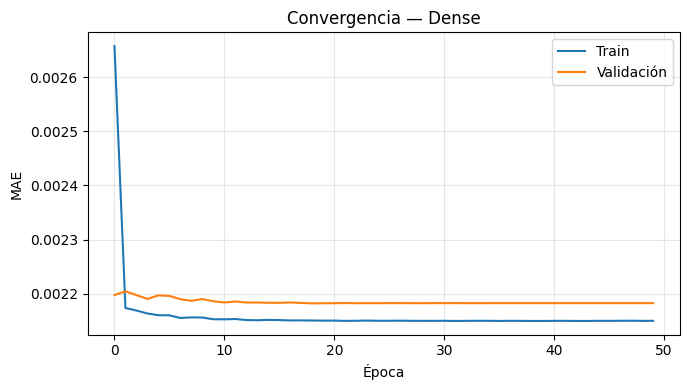

In [26]:
graficar_convergencia(hist_dense_1, 'Dense')
resultado_dense_1 = evaluar_modelo(modelo_dense_1, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_1)

{'modelo': 'Dense', 'mae_train': 0.0023775313677953437, 'mae_val': 0.002497999919973683, 'mae_test': 0.0026722254864213263, 'n_params': 212759}


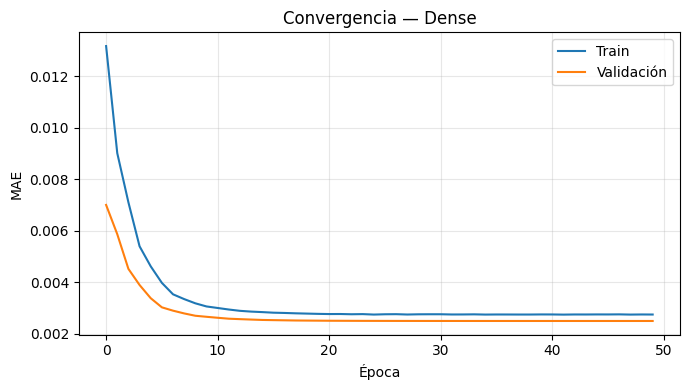

In [18]:
graficar_convergencia(hist_dense_2, 'Dense')
resultado_dense_2 = evaluar_modelo(modelo_dense_2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_2)

{'modelo': 'Dense', 'mae_train': 0.0023676075532678433, 'mae_val': 0.002459587251927278, 'mae_test': 0.002617355109023391, 'n_params': 212759}


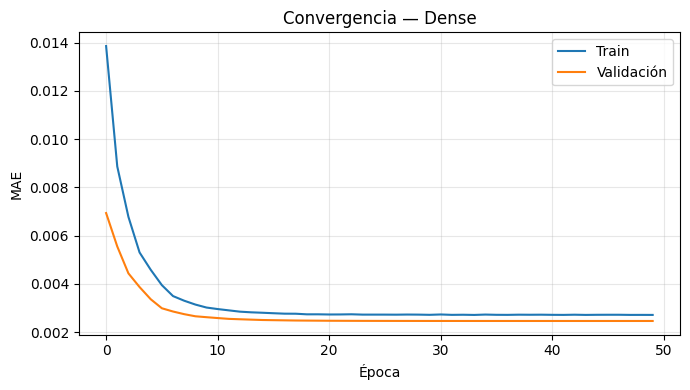

In [19]:
graficar_convergencia(hist_dense_3, 'Dense')
resultado_dense_3 = evaluar_modelo(modelo_dense_3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_3)

{'modelo': 'Dense', 'mae_train': 0.0023692362147234606, 'mae_val': 0.002452965119720315, 'mae_test': 0.0026710927861074538, 'n_params': 212759}


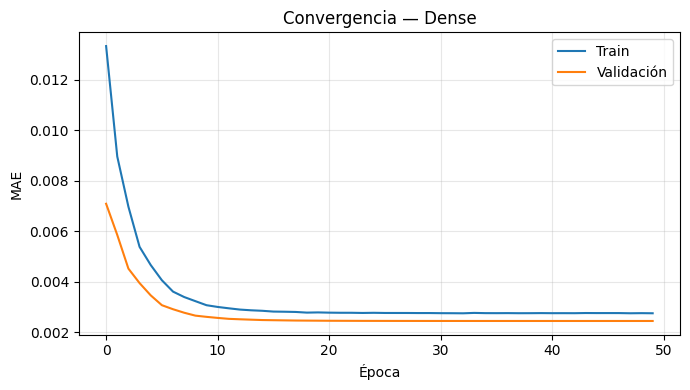

In [20]:
graficar_convergencia(hist_dense_4, 'Dense')
resultado_dense_4 = evaluar_modelo(modelo_dense_4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_4)

{'modelo': 'Dense', 'mae_train': 0.0022842168396202144, 'mae_val': 0.00237948026703115, 'mae_test': 0.0025329373375308135, 'n_params': 212759}


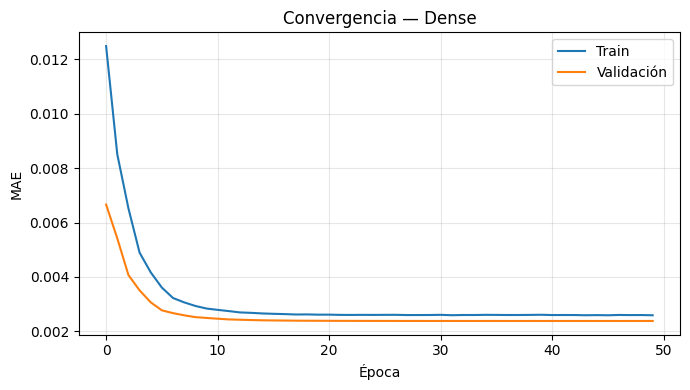

In [21]:
graficar_convergencia(hist_dense_5, 'Dense')
resultado_dense_5 = evaluar_modelo(modelo_dense_5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_5)

{'modelo': 'Dense', 'mae_train': 0.0024417253007633886, 'mae_val': 0.002567248243309033, 'mae_test': 0.0027317481731481638, 'n_params': 212759}


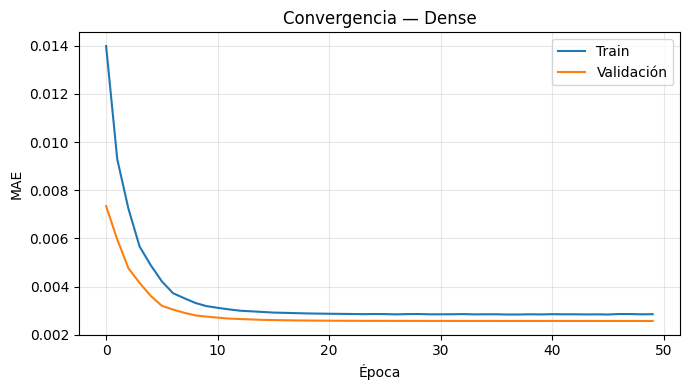

In [22]:
graficar_convergencia(hist_dense_6, 'Dense')
resultado_dense_6 = evaluar_modelo(modelo_dense_6, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_6)

In [29]:
base_cfg = {
    "epochs": 75,
    "batch_size": 500,
    "lr": 1e-3,          # se aplica por recompilación runtime
    "factor": 0.5,
    "rlr_patience": 3,
    "min_delta": 1e-5,
    "min_lr": 1e-6,
    "seed": 42,
    "verbose": 0 # Para evitar imprimir cada epoch durante el tuning
}

search_steps = [
    ("lr", [1e-3, 5e-4, 3e-4, 1e-4]),
    ("batch_size", [250, 1000, 5000, 10000, 14000]),
    ("factor", [0.3, 0.5, 0.7]),
    ("rlr_patience", [2, 3, 5]),
    ("min_delta", [1e-6, 1e-5, 1e-4]),
    ("min_lr", [1e-6, 1e-5, 1e-4]),
    ("epochs", [30, 50, 80, 100])
]


Buscando hiperparámetros para construir_dense...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr           -> mejor: 0.001 | val_loss=0.002188 (época 15)
batch_size   -> mejor: 1000 | val_loss=0.002186 (época 9)
factor       -> mejor: 0.7 | val_loss=0.002186 (época 11)
rlr_patience -> mejor: 5 | val_loss=0.002186 (época 19)
min_delta    -> mejor: 1e-06 | val_loss=0.002185 (época 28)
min_lr       -> mejor: 1e-06 | val_loss=0.002185 (época 28)
epochs       -> mejor: 75 | val_loss=0.002185 (época 28)

Buscando hiperparámetros para construir_dense_v2...
lr           -> mejor: 0.001 | val_loss=0.002184 (época 75)
batch_size   -> mejor: 250 | val_loss=0.002183 (época 15)
factor       -> mejor: 0.7 | val_loss=0.002183 (época 31)
rlr_patience -> mejor: 3 | val_loss=0.002183 (época 31)
min_delta    -> mejor: 1e-05 | val_loss=0.002183 (época 31)
min_lr       -> mejor: 1e-06 | val_loss=0.002183 (época 31)
epochs       -> mejor: 75 | val_loss=0.002183 (época 31)

Buscando hiperparámetros para construir_dense_v3...
lr           -> mejor: 0.001 | val_loss=0.002183 (época 11)
batch_size   -> 

,modelo,mae_train,mae_test,n_params,best_cfg,mejor_test
0,construir_dense_v4,0.002151,0.002320,98199,"{""epochs"": 75, ""batch_size"": 250, ""lr"": 0.001,...",<-- MEJOR
1,construir_dense_v3,0.002149,0.002320,527767,"{""epochs"": 75, ""batch_size"": 1000, ""lr"": 0.001...",
2,construir_dense_v2,0.002151,0.002320,99543,"{""epochs"": 75, ""batch_size"": 250, ""lr"": 0.001,...",
3,construir_dense,0.002146,0.002321,212759,"{""epochs"": 75, ""batch_size"": 1000, ""lr"": 0.001...",
4,construir_dense_v6,0.002146,0.002322,35511,"{""epochs"": 75, ""batch_size"": 250, ""lr"": 0.0003...",
5,construir_dense_v5,0.002087,0.002358,182807,"{""epochs"": 75, ""batch_size"": 500, ""lr"": 0.0005...",


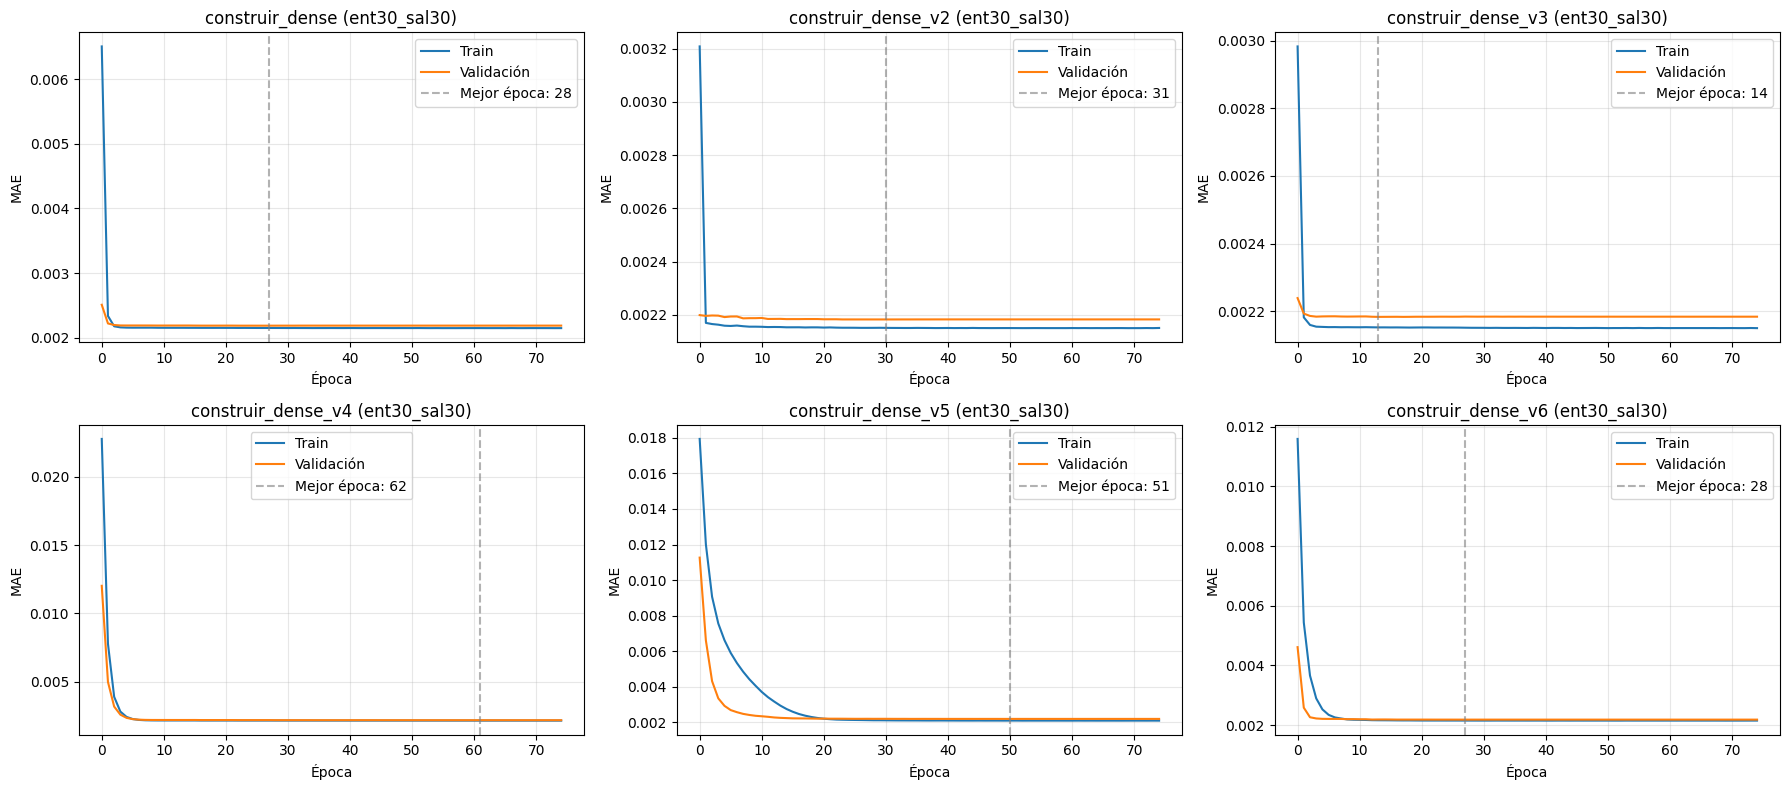

<Figure size 640x480 with 0 Axes>

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr           -> mejor: 0.001 | val_loss=0.002184 (época 75)
batch_size   -> mejor: 250 | val_loss=0.002183 (época 15)
factor       -> mejor: 0.7 | val_loss=0.002183 (época 31)
rlr_patience -> mejor: 3 | val_loss=0.002183 (época 31)
min_delta    -> mejor: 1e-05 | val_loss=0.002183 (época 31)
min_lr       -> mejor: 1e-06 | val_loss=0.002183 (época 31)
epochs       -> mejor: 75 | val_loss=0.002183 (época 31)
Mejor configuración: {'epochs': 75, 'batch_size': 250, 'lr': 0.001, 'factor': 0.7, 'rlr_patience': 3, 'min_delta': 1e-05, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0}
Mejor val_loss: 0.002183 (época 31)


,param,value,best_val_loss,best_epoch,epochs,batch_size,lr,factor,rlr_patience,min_delta,min_lr,seed,verbose
0,factor,0.7,0.002183,31,75,250,0.001,0.7,3,0.000010,0.000001,42,0
1,rlr_patience,3,0.002183,31,75,250,0.001,0.7,3,0.000010,0.000001,42,0
2,epochs,80,0.002183,31,80,250,0.001,0.7,3,0.000010,0.000001,42,0
3,epochs,100,0.002183,31,100,250,0.001,0.7,3,0.000010,0.000001,42,0
4,min_lr,0.00001,0.002183,31,75,250,0.001,0.7,3,0.000010,0.000010,42,0
5,epochs,50,0.002183,31,50,250,0.001,0.7,3,0.000010,0.000001,42,0
6,min_lr,0.000001,0.002183,31,75,250,0.001,0.7,3,0.000010,0.000001,42,0
7,min_delta,0.00001,0.002183,31,75,250,0.001,0.7,3,0.000010,0.000001,42,0
8,min_delta,0.0001,0.002183,31,75,250,0.001,0.7,3,0.000100,0.000001,42,0
9,min_delta,0.000001,0.002183,36,75,250,0.001,0.7,3,0.000001,0.000001,42,0


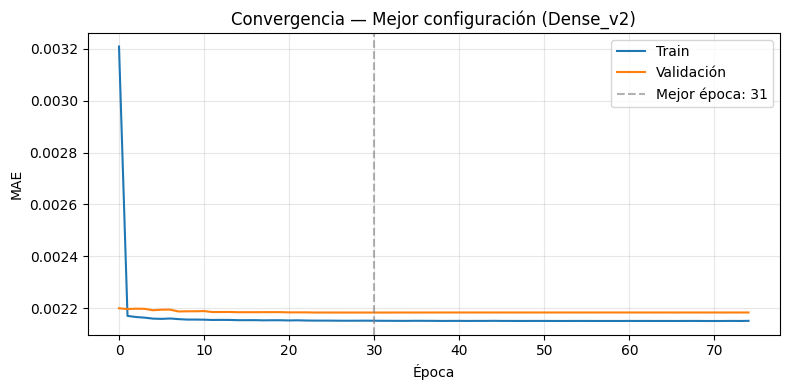

In [34]:
import json

dense_models = [
    "construir_dense",
    "construir_dense_v2",
    "construir_dense_v3",
    "construir_dense_v4",
    "construir_dense_v5",
    "construir_dense_v6",
]

resumen = []
best_histories = {}

for fn_name in dense_models:
    print(f"\n{'='*60}\nBuscando hiperparámetros para {fn_name}...\n{'='*60}")

    best_cfg, best_val, best_epoch, best_hist, best_model, df_trials = ofat_search(
        model_fn_name=fn_name,
        base_cfg=base_cfg.copy(),
        search_steps=search_steps,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val
    )

    met = evaluar_modelo(
        best_model,
        X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=fn_name
    )

    resumen.append({
        "modelo": fn_name,
        "mae_train": met["mae_train"],      
        "mae_val": met["mae_val"],          
        "mae_test": met["mae_test"],        
        "n_params": met["n_params"],
        "best_val_loss": best_val,
        "best_epoch": best_epoch,
        "best_cfg": json.dumps(best_cfg, ensure_ascii=False)
    })
    best_histories[fn_name] = best_hist

# Tabla resumen
resumen_df = pd.DataFrame(resumen).sort_values("mae_test").reset_index(drop=True)
cols = ["modelo", "mae_train", "mae_test", "n_params", "best_cfg"]
tabla = resumen_df[cols].copy()
tabla["mae_train"] = tabla["mae_train"].map(lambda x: f"{x:.6f}")
tabla["mae_test"] = tabla["mae_test"].map(lambda x: f"{x:.6f}")
tabla["mejor_test"] = ""

best_idx = resumen_df["mae_test"].idxmin()
tabla.loc[best_idx, "mejor_test"] = "<-- MEJOR"

display(tabla)

# Pintar TODAS las mejores curvas (una por modelo)
n = len(best_histories)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, hist) in zip(axes, best_histories.items()):
    best_ep = int(np.argmin(hist.history["val_loss"])) + 1
    ax.plot(hist.history["loss"], label="Train")
    ax.plot(hist.history["val_loss"], label="Validación")
    ax.axvline(best_ep - 1, color="gray", ls="--", alpha=0.6, label=f"Mejor época: {best_ep}")
    ax.set_title(f"{name} (ent{VENTANA_ENTRADA}_sal{VENTANA_SALIDA})")
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE")
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()

best_cfg, best_val, best_epoch, best_hist, best_model, df_trials = ofat_search(
    model_fn_name="construir_dense_v2",
    base_cfg=base_cfg,
    search_steps=search_steps,
    X_train=X_train, y_train=y_train,      # puede ser 3D; se aplana solo para Dense
    X_val=X_val, y_val=y_val
)

print("Mejor configuración:", best_cfg)
print(f"Mejor val_loss: {best_val:.6f} (época {best_epoch})")
display(df_trials.head(15))
plot_best_history(best_hist, "Convergencia — Mejor configuración (Dense_v2)")


## 1.4 Modelo Recurrente (LSTM)

In [ ]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


In [ ]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)


## 1.5 Modelo Conv1D

In [ ]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


In [ ]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)


## 1.6 Modelo Mixto (Conv1D + LSTM)

In [ ]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


In [ ]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

In [ ]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [ ]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


In [ ]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [ ]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


In [ ]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [ ]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

In [ ]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

In [ ]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
